# Tour

> What ItemiSet does, in ten minutes.

A Venn diagram tells you that 24 proteins were found by all three baits. It doesn't tell you which 24, so the next step is always a lookup table. ItemiSet puts the table inside the diagram: every item gets one cell, so a region's area is its count, and its contents can be read straight off the figure.

```sh
pip install git+https://github.com/adamcc/itemiset
```

In [ ]:
#| hide
from fastcore.test import *
import tempfile
from pathlib import Path
import pandas as pd

In [ ]:
import itemiset
from itemiset import plot, load_example, load_sets, zone_rows, check_layout

## A first diagram

The bundled `pbody` example holds the high-confidence BioID hits of three P-body baits from [Youn *et al.* (2018)](https://doi.org/10.1016/j.molcel.2017.12.020), via BioGRID. (See [example data](examples.html) for how it was made.)

In [ ]:
ex = load_example("pbody")
{name: len(items) for name, items in ex["sets"].items()}

{'DDX6': 42, 'LSM14A': 84, 'EIF4ENIF1': 62}

`plot` takes sets as `{name: [items]}` and returns a `Layout`, which shows its figure in a notebook:

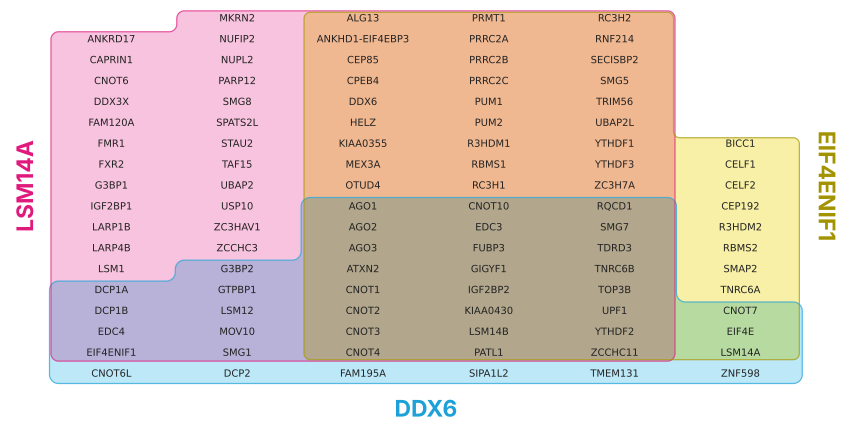

In [ ]:
lay = plot(ex["sets"])
lay

Reading it:

- **Position is membership.** Each set is outlined in its own colour: DDX6 cyan, LSM14A magenta and EIF4ENIF1 yellow, in input order. Overlaps are coloured by multiplying the tints, like overlapping inks.
- **Area is the count.** One cell per protein, so the 24 proteins found by all three baits fill exactly 24 cells.
- **Text is the identity.** The names sort naturally within each region (CNOT2 before CNOT10), reading down each column.

## Colouring names by category

Categories colour the item names, for example to highlight GO terms or complexes. Colours you don't give are taken from a palette.

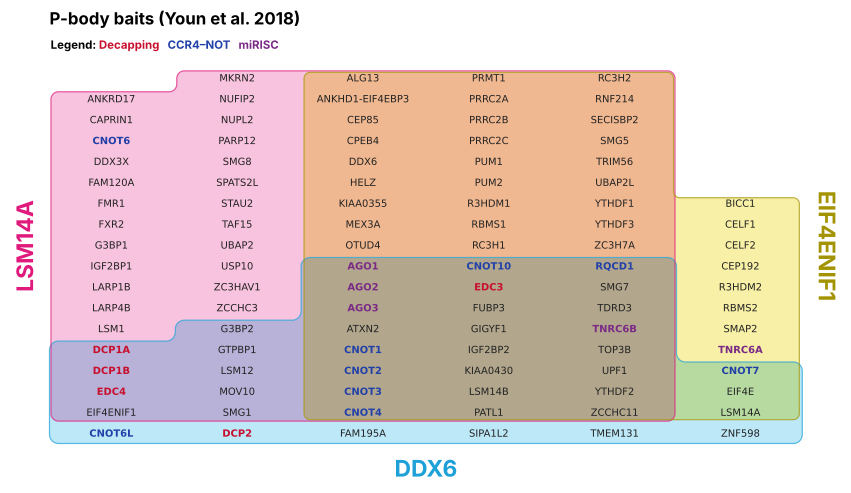

In [ ]:
lay = plot(ex["sets"], categories=ex["categories"], category_colours=ex["category_colours"],
           title="P-body baits (Youn et al. 2018)")
lay

## What the layout chose

The layout picks which set goes along the bottom, and how wide each column group is. It also reports anything you should know, such as filler cells or empty sets left out:

In [ ]:
lay.roles, lay.widths, lay.notes

({'A': 'LSM14A', 'B': 'EIF4ENIF1', 'C': 'DDX6'}, (2, 3, 1), [])

`zone_rows` lists every item with its zone, which is handy as a supplementary table:

In [ ]:
pd.DataFrame(zone_rows(lay, ex["categories"])).head(8)

,item,zone,DDX6,LSM14A,EIF4ENIF1,category
0,CNOT6L,DDX6,1,0,0,CCR4–NOT
1,DCP2,DDX6,1,0,0,Decapping
2,FAM195A,DDX6,1,0,0,
3,SIPA1L2,DDX6,1,0,0,
4,TMEM131,DDX6,1,0,0,
5,ZNF598,DDX6,1,0,0,
6,CNOT7,DDX6 & EIF4ENIF1,1,0,1,CCR4–NOT
7,EIF4E,DDX6 & EIF4ENIF1,1,0,1,


## Changing the layout

Put a particular set along the bottom with `bottom`, and change the overall shape with `target_aspect` (width ÷ height, 2.2 by default):

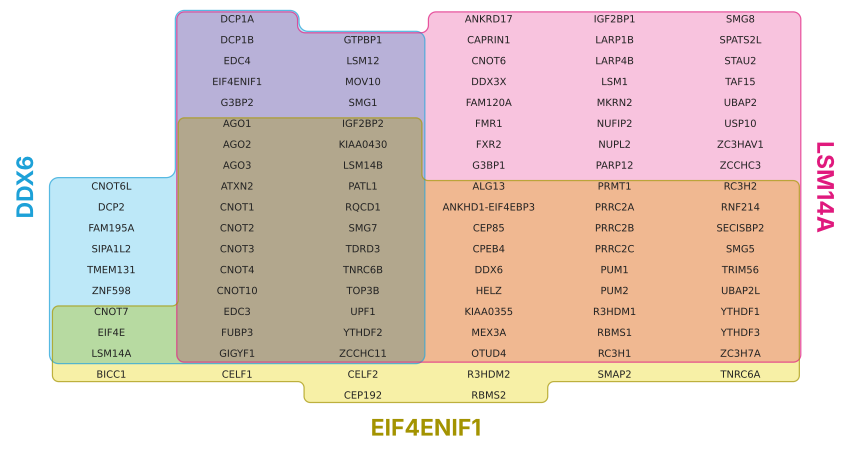

In [ ]:
plot(ex["sets"], bottom="EIF4ENIF1", target_aspect=1.2)

## Venn mode: showing empty zones

An Euler diagram only draws the overlaps that exist. In the `decay` example nothing is found by DDX6 and PRRC2B alone, so that region is simply absent. With `show_empty=True` every empty zone gets one ∅ cell, which makes the diagram a Venn diagram. Those cells aren't proportional, and the layout says so in its notes.

["1 empty zone(s) shown as '∅' placeholder cells (1 cell each; not area-proportional)."]


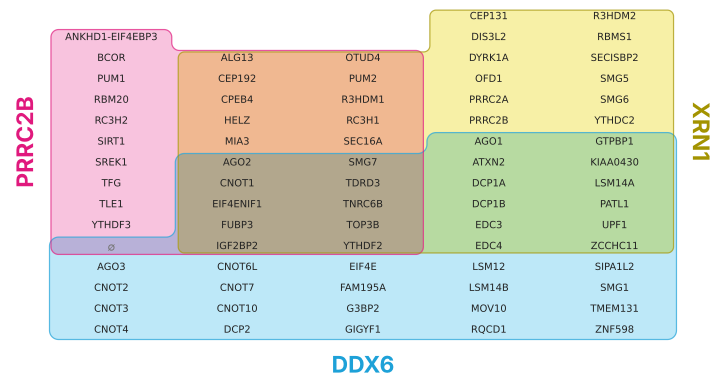

In [ ]:
dec = load_example("decay")
lay_v = plot(dec["sets"], show_empty=True)
print(lay_v.notes)
lay_v

## Your own data

`load_sets` reads CSV, TSV and Excel files, as a membership table or as one column per set (see [readers](readers.html)). Here is a small file with one column per set:

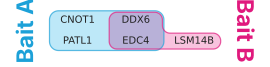

In [ ]:
tmp = Path(tempfile.mkdtemp())
(tmp/"hits.csv").write_text(
    "Bait A,Bait B\n"
    "EDC4,EDC4\n"
    "PATL1,LSM14B\n"
    "DDX6,DDX6\n"
    "CNOT1,\n")
sets, categories, colours = load_sets(tmp/"hits.csv")
plot(sets, out=tmp/"hits.pdf")

The output format follows the file extension: `.png`, `.pdf` or `.svg`. PDF and SVG keep the names as text, so they stay editable.

The same thing from the command line:

```sh
itemiset hits.csv -o hits.pdf --zones-out zones.csv
```

## Every layout is checked

Every layout should have five properties. `check_layout` tests them, and the [tests](edge_cases.html) run it on every figure:

In [ ]:
check_layout(lay, ex["sets"])

{'One cell per item': True,
 'Each set is one piece': True,
 'No set has a hole': True,
 'Each zone is one piece': True,
 'No stray white pockets': True}

In [ ]:
#| hide
assert all(check_layout(lay, ex["sets"]).values())
test_eq(lay.n_items, 101)

## In the browser

The [web app](https://adamcc.github.io/itemiset/app.html) runs the same layout, ported to JavaScript, with no installation. It gives identical layouts for the same inputs (see [fixtures](fixtures.html)), and adds font weight for a number per item.

## Why it stops at three sets

Light cyan, magenta and yellow give exactly seven distinguishable overlap colours, one for each zone of three sets. Beyond three, real data often can't be drawn with one cell per item at all: five baits sharing a single prey would need that one cell to touch five private regions, and a cell has four sides. For four or more sets, an itemized [UpSet](https://upset.app) plot is the better tool.